Generating Synthetic Heteroscedastic Universe...
Generated 1000 synthetic mock lenses.

--- Running MCMC ---
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0', 'beta_c1']


100%|██████████| 1000/1000 [03:01<00:00,  5.52it/s]


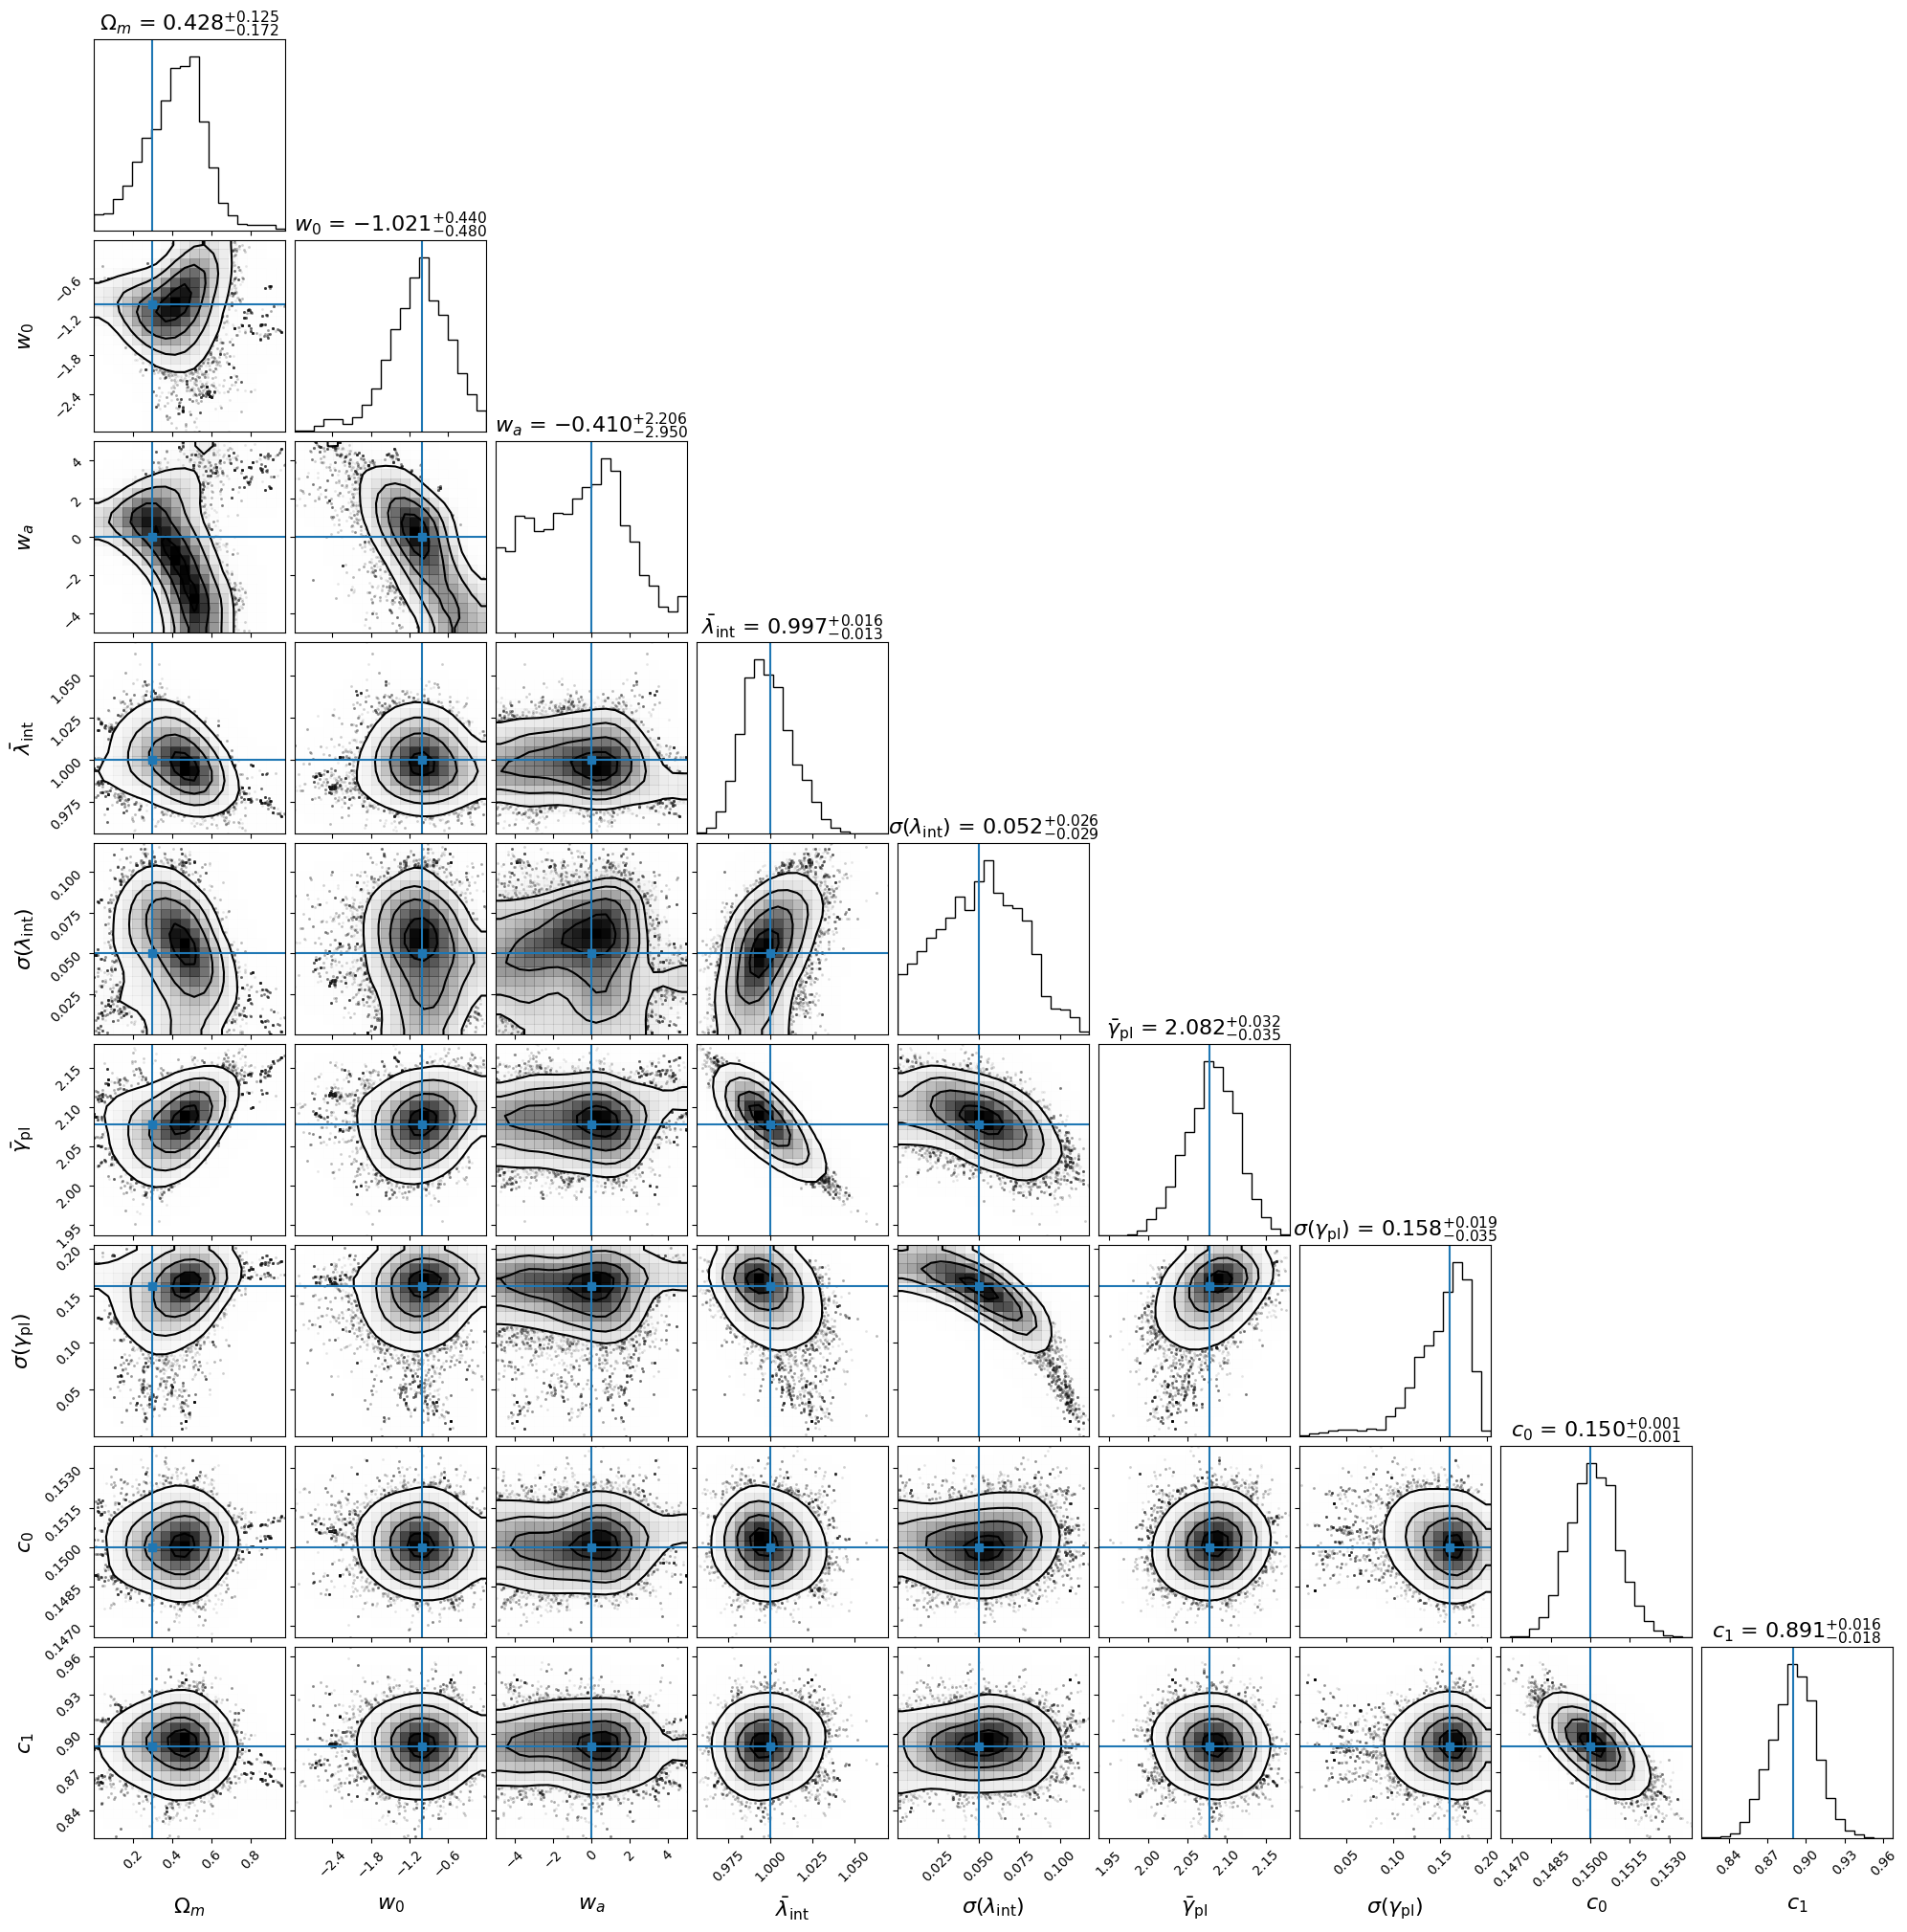

In [1]:
import numpy as np
from astropy.cosmology import Flatw0waCDM
from dspl_inference_unified import draw_lens_from_given_zs, run_dspl_inference
import corner
import matplotlib.pyplot as plt
np.random.seed(42)

# --- 1. CONFIGURATION & TRUTH ---
# We define our exact underlying universe, including the polynomial coefficients 
# that govern how intrinsic scatter scales with dissimilarity.
truth = {
    'h0': 70.0, 
    'om': 0.3, 
    'w0': -1.0, 
    'wa': 0.0,
    'lambda_int': 1.0, 
    'lambda_sigma': 0.05,
    'gamma_pl': 2.078, 
    'gamma_sigma': 0.16,
    'beta_c0': 0.15,  # Baseline intrinsic scatter (2%)
    'beta_c1': 0.89,   # Strong linear scaling with dissimilarity
    'beta_c2': 0.0    # No quadratic scaling
}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

# --- 2. GENERATE SYNTHETIC HETEROSCEDASTIC DATA ---
print("Generating Synthetic Heteroscedastic Universe...")
kwargs_list = []
num_lenses = 1000
down_sampling = 86 # Simulate 86,000 effective lenses

for _ in range(num_lenses):
    # 1. Random geometry
    z_lens = np.random.normal(loc=0.5, scale=0.1)
    z1 = np.random.uniform(low=z_lens + 0.1, high=3.0)
    z2 = np.random.uniform(low=z1 + 0.1, high=3.0)
    
    # 2. Random dissimilarity score (simulating a range from 0 to 0.1)
    dissimilarity = np.random.uniform(0.0, 0.1)
    
    # 3. Calculate this specific lens's true intrinsic scatter
    true_lens_intrinsic_scatter = truth['beta_c0'] + (truth['beta_c1'] * dissimilarity)
    
    # 4. Standard observational errors
    sigma_beta_meas, sigma_beta_los = 0.01, 0.01
    sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
    
    kwargs_list.append(draw_lens_from_given_zs(
        z_lens=z_lens, z1=z1, z2=z2,
        lambda_mst_mean=truth['lambda_int'], 
        lambda_mst_sigma=truth['lambda_sigma'],
        gamma_pl_mean=truth['gamma_pl'], 
        gamma_pl_sigma=truth['gamma_sigma'],
        sigma_beta_intrinsic=true_lens_intrinsic_scatter, 
        sigma_meas_rel=sigma_meas_rel,
        dissimilarity=dissimilarity, # <--- Inject the generated metric here
        down_sampling=down_sampling, 
        with_noise=False, 
        cosmo=cosmo_true,
        redshift_error_rel=0.03
    ))

print(f"Generated {len(kwargs_list)} synthetic mock lenses.")

# --- 3. CONFIGURE MCMC INFERENCE ---
# We explicitly fix the quadratic term (c2) to 0.0 since we know our 
# synthetic universe is purely linear.
fixed_params = {
    'h0': 70.0,
    'beta_c2': 0.0
}

my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16,
    'beta_c0': 0.15, 'beta_c1': 0.89
}

my_spreads = {
    'om': 0.05, 'w0': 0.05, 'wa': 0.05,
    'lambda_int': 0.05, 'lambda_sigma': 0.02,
    'gamma_pl': 0.05, 'gamma_sigma': 0.02,
    'beta_c0': 0.01, 'beta_c1': 0.5
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5),
    'beta_c0': ('uniform', -1.0, 1.0),
    'beta_c1': ('uniform', -5.0, 5.0)
}

# --- 4. RUN INFERENCE ---
print("\n--- Running MCMC ---")
samples, labels = run_dspl_inference(
    kwargs_list,
    down_sampling=down_sampling,
    n_walkers=64, 
    n_steps=1000, 
    n_burn=500,
    initial_guess=my_guess, 
    initial_scatter=my_spreads,
    fixed_params=fixed_params,
    priors=my_priors
)

# --- 5. PLOT CORNER ---
# Dynamically build the truths list for whatever parameters were sampled
sampled_param_names = [p for p in my_guess.keys() if p not in fixed_params]
full_truths_list = [truth[name] for name in sampled_param_names]

fig = corner.corner(
    samples, 
    labels=labels, 
    truths=full_truths_list,
    truth_color="#1f77b4",
    smooth=1.5,
    show_titles=True,
    title_fmt=".3f", 
    title_kwargs={"fontsize": 16},  
    label_kwargs={"fontsize": 16} 
)

plt.show()


--- Running MCMC ---
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0']


100%|██████████| 1000/1000 [03:03<00:00,  5.45it/s]


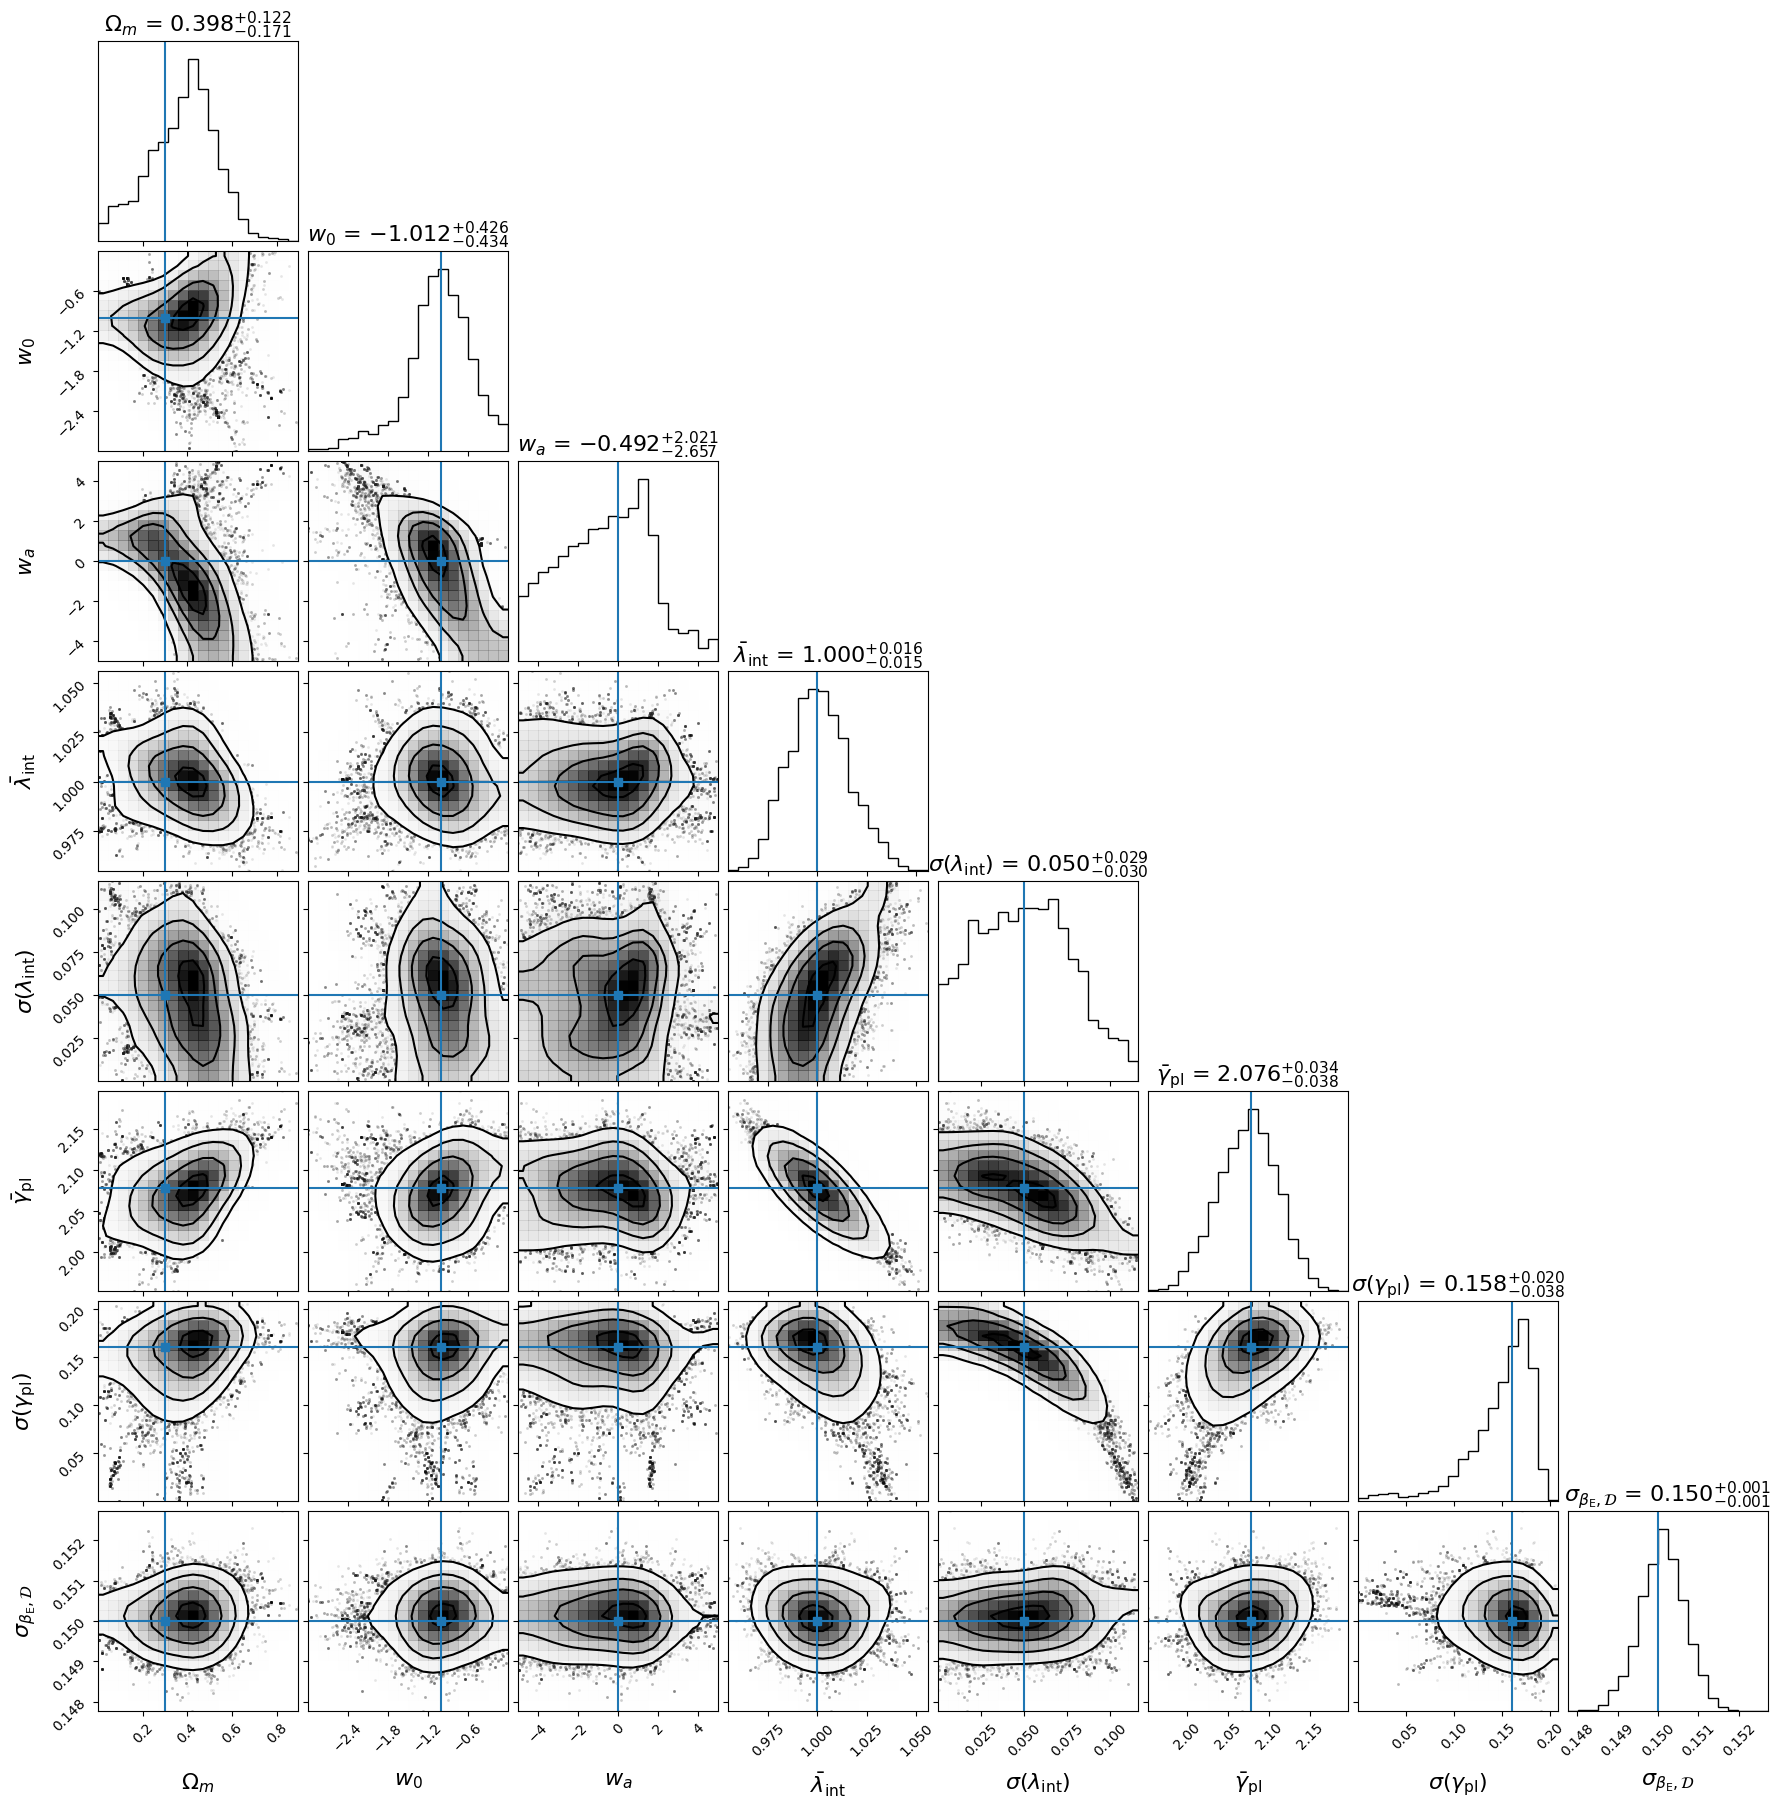

In [2]:
# --- 3. CONFIGURE MCMC INFERENCE ---
# We explicitly fix the quadratic term (c2) to 0.0 since we know our 
# synthetic universe is purely linear.
fixed_params = {
    'h0': 70.0,
    'beta_c1': 0.89,
    'beta_c2': 0.0
}

my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16,
    'beta_c0': 0.15, 'beta_c1': 0.89,
}

my_spreads = {
    'om': 0.05, 'w0': 0.05, 'wa': 0.05,
    'lambda_int': 0.05, 'lambda_sigma': 0.02,
    'gamma_pl': 0.05, 'gamma_sigma': 0.02,
    'beta_c0': 0.01, 'beta_c1': 0.5
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5),
    'beta_c0': ('uniform', -1.0, 1.0),
    'beta_c1': ('uniform', -5.0, 5.0)
}

# --- 4. RUN INFERENCE ---
print("\n--- Running MCMC ---")
samples, labels = run_dspl_inference(
    kwargs_list,
    down_sampling=down_sampling,
    n_walkers=64, 
    n_steps=1000, 
    n_burn=500,
    initial_guess=my_guess, 
    initial_scatter=my_spreads,
    fixed_params=fixed_params,
    priors=my_priors
)

# --- 5. PLOT CORNER ---
# Dynamically build the truths list for whatever parameters were sampled
sampled_param_names = [p for p in my_guess.keys() if p not in fixed_params]
full_truths_list = [truth[name] for name in sampled_param_names]

fig = corner.corner(
    samples, 
    labels=labels, 
    truths=full_truths_list,
    truth_color="#1f77b4",
    smooth=1.5,
    show_titles=True,
    title_fmt=".3f", 
    title_kwargs={"fontsize": 16},  
    label_kwargs={"fontsize": 16} 
)

plt.show()


--- Running MCMC ---
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0']


100%|██████████| 1000/1000 [03:03<00:00,  5.45it/s]


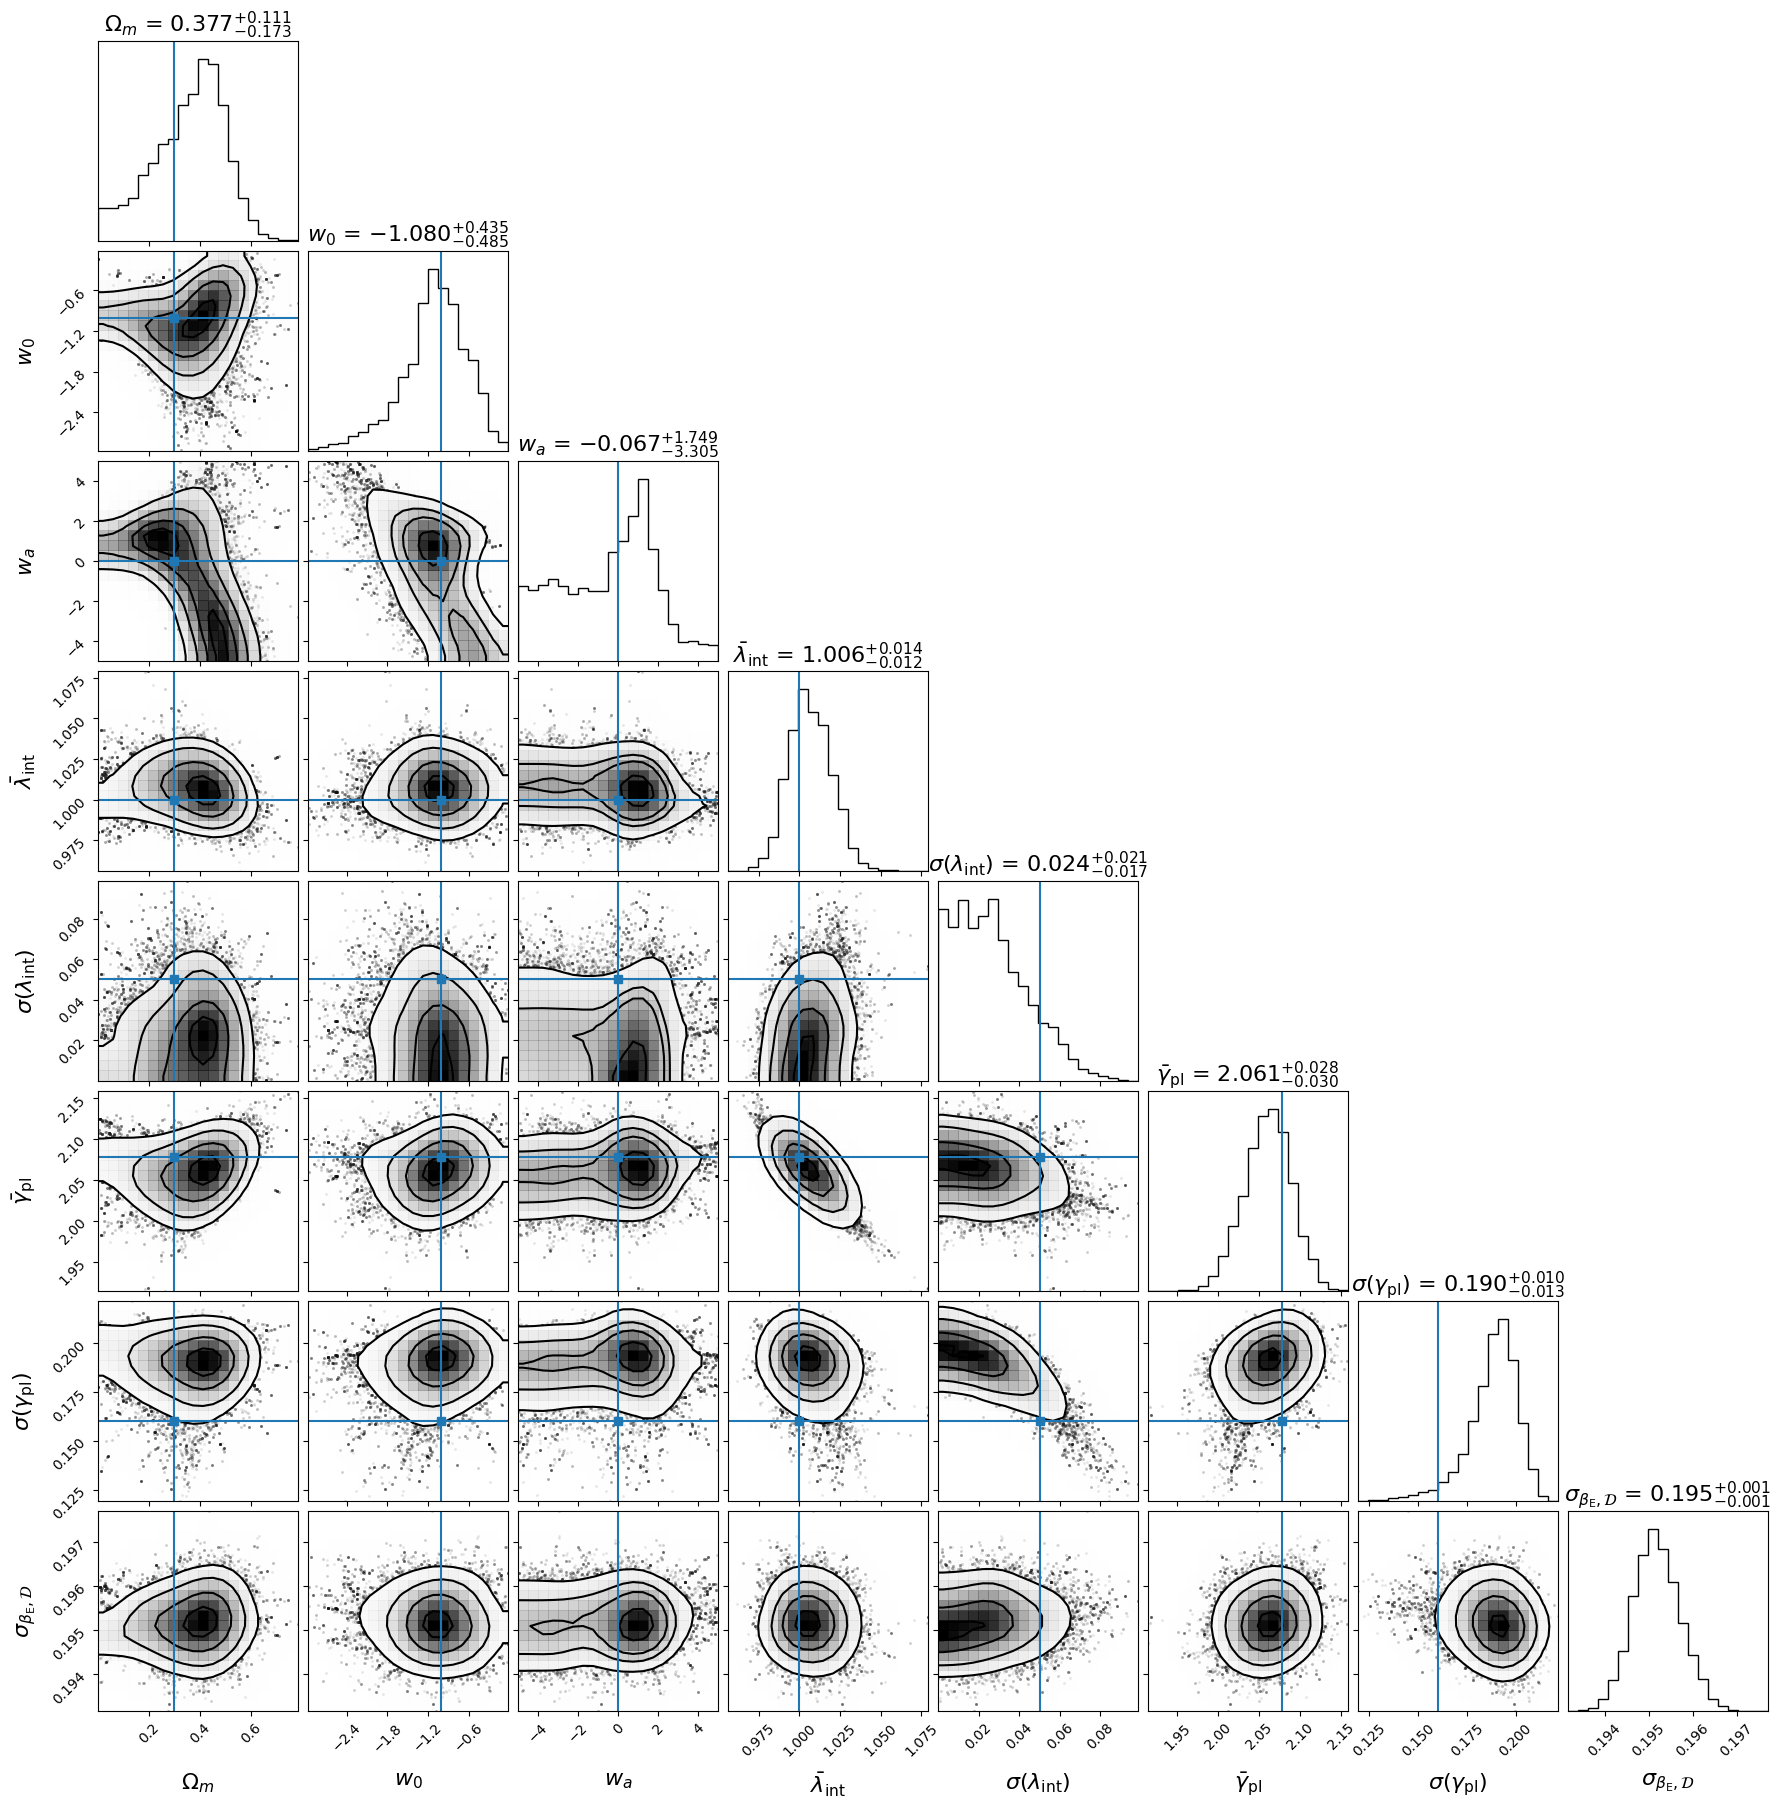

In [3]:
# --- 3. CONFIGURE MCMC INFERENCE ---
# We explicitly fix the quadratic term (c2) to 0.0 since we know our 
# synthetic universe is purely linear.
fixed_params = {
    'h0': 70.0,
    'beta_c1': 0.00,
    'beta_c2': 0.0
}

my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16,
    'beta_c0': 0.15, 'beta_c1': 0.00,
}

my_spreads = {
    'om': 0.05, 'w0': 0.05, 'wa': 0.05,
    'lambda_int': 0.05, 'lambda_sigma': 0.02,
    'gamma_pl': 0.05, 'gamma_sigma': 0.02,
    'beta_c0': 0.01, 'beta_c1': 0.5
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5),
    'beta_c0': ('uniform', -1.0, 1.0),
    'beta_c1': ('uniform', -5.0, 5.0)
}

# --- 4. RUN INFERENCE ---
print("\n--- Running MCMC ---")
samples, labels = run_dspl_inference(
    kwargs_list,
    down_sampling=down_sampling,
    n_walkers=64, 
    n_steps=1000, 
    n_burn=500,
    initial_guess=my_guess, 
    initial_scatter=my_spreads,
    fixed_params=fixed_params,
    priors=my_priors
)

# --- 5. PLOT CORNER ---
# Dynamically build the truths list for whatever parameters were sampled
sampled_param_names = [p for p in my_guess.keys() if p not in fixed_params]
full_truths_list = [truth[name] for name in sampled_param_names]

fig = corner.corner(
    samples, 
    labels=labels, 
    truths=full_truths_list,
    truth_color="#1f77b4",
    smooth=1.5,
    show_titles=True,
    title_fmt=".3f", 
    title_kwargs={"fontsize": 16},  
    label_kwargs={"fontsize": 16} 
)

plt.show()